# 03 — U-Net Segmentation Evaluation
**Results:** Mean IoU=0.6030 ± 0.0201 | Test IoU=0.5694 | Dice=0.6654 | Sensitivity=0.7015

This notebook:
1. Loads the best U-Net checkpoint
2. Evaluates on the held-out test set
3. Shows best and worst predictions
4. Reconstructs full mammogram masks
5. Threshold analysis
6. Final metrics report

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import torch
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.metrics import roc_curve, auc, precision_recall_curve

from src.models.unet import UNet
from src.models.losses import iou_coefficient, dice_coefficient, sensitivity_score
from src.dataset.seg_dataset import SegDataset, load_fold_paths

DEVICE    ='cpu'
CKPT      = Path('../checkpoints/unet_best.pth')
TEST_DIR  = Path('../data/patches/segmentation/test')
ALL_DIR   = Path('../data/patches/segmentation/all')

print(f'Device: {DEVICE}')
print(f'Checkpoint exists: {CKPT.exists()}')

Device: cpu
Checkpoint exists: True


## 1. Load Model

In [2]:
model = UNet(in_channels=1, out_channels=1, base_ch=64).to(DEVICE)
ckpt  = torch.load(str(CKPT), map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Loaded: fold={ckpt["fold"]} epoch={ckpt["epoch"]} val_iou={ckpt["val_iou"]:.4f}')
print(f'Params: {sum(p.numel() for p in model.parameters()):,}')

Loaded: fold=3 epoch=215 val_iou=0.6324
Params: 31,036,481


## 2. Full Test Set Evaluation

In [3]:
test_imgs, test_masks = load_fold_paths(TEST_DIR)
print(f'Test patches: {len(test_imgs)}')

all_ious, all_dices, all_sens = [], [], []
all_probs, all_labels = [], []

for img_path, mask_path in tqdm(zip(test_imgs, test_masks),
                                total=len(test_imgs)):
    img  = cv2.imread(str(img_path),  cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    t = torch.tensor(img.astype(np.float32)/255.0
                     ).unsqueeze(0).unsqueeze(0).to(DEVICE)
    m = torch.tensor((mask>0).astype(np.float32)
                     ).unsqueeze(0).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(t)

    all_ious.append(iou_coefficient(logits, m))
    all_dices.append(dice_coefficient(logits, m))
    all_sens.append(sensitivity_score(logits, m))

    prob  = torch.sigmoid(logits).cpu().numpy().flatten()
    label = m.cpu().numpy().flatten().astype(int)
    all_probs.extend(prob.tolist())
    all_labels.extend(label.tolist())

print(f'\n{"="*45}')
print(f'  TEST SET RESULTS')
print(f'{"="*45}')
print(f'  IoU         : {np.mean(all_ious):.4f} ± {np.std(all_ious):.4f}')
print(f'  Dice        : {np.mean(all_dices):.4f} ± {np.std(all_dices):.4f}')
print(f'  Sensitivity : {np.mean(all_sens):.4f} ± {np.std(all_sens):.4f}')
print(f'{"="*45}')

Test patches: 184


  0%|          | 0/184 [00:00<?, ?it/s]


  TEST SET RESULTS
  IoU         : 0.5694 ± 0.2870
  Dice        : 0.6654 ± 0.2955
  Sensitivity : 0.7015 ± 0.3082


## 3. ROC Curve and AUC

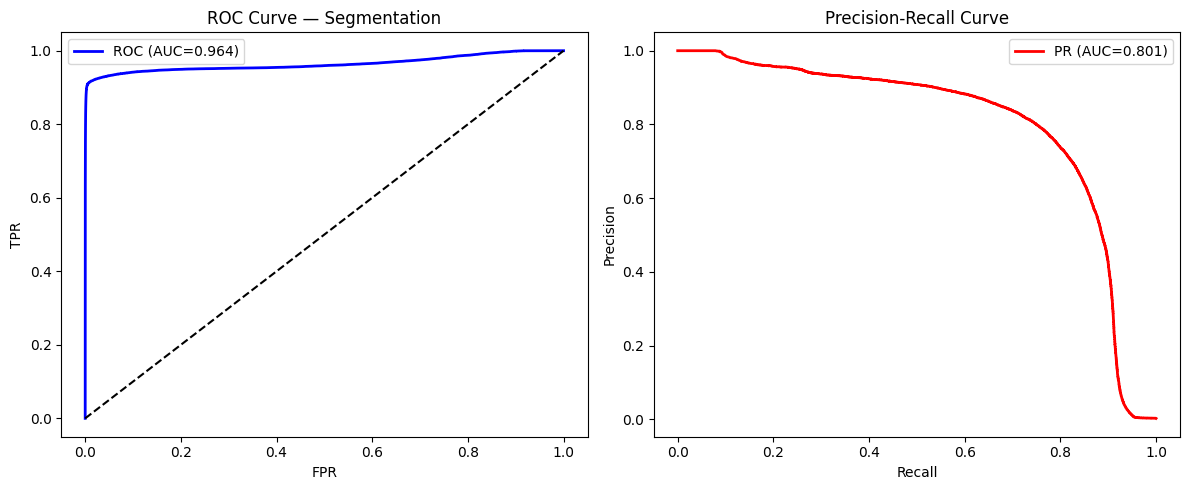

AUC-ROC: 0.9642
AUC-PR : 0.8009


In [4]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc_roc     = auc(fpr, tpr)
prec, rec, _= precision_recall_curve(all_labels, all_probs)
auc_pr      = auc(rec, prec)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC={auc_roc:.3f})')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve — Segmentation')
axes[0].legend()

axes[1].plot(rec, prec, 'r-', lw=2, label=f'PR (AUC={auc_pr:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f'AUC-ROC: {auc_roc:.4f}')
print(f'AUC-PR : {auc_pr:.4f}')

## 4. Best and Worst Predictions

C:\Users\amine\AppData\Local\Temp\ipykernel_11092\464767592.py:23: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\project\mammo-cad\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


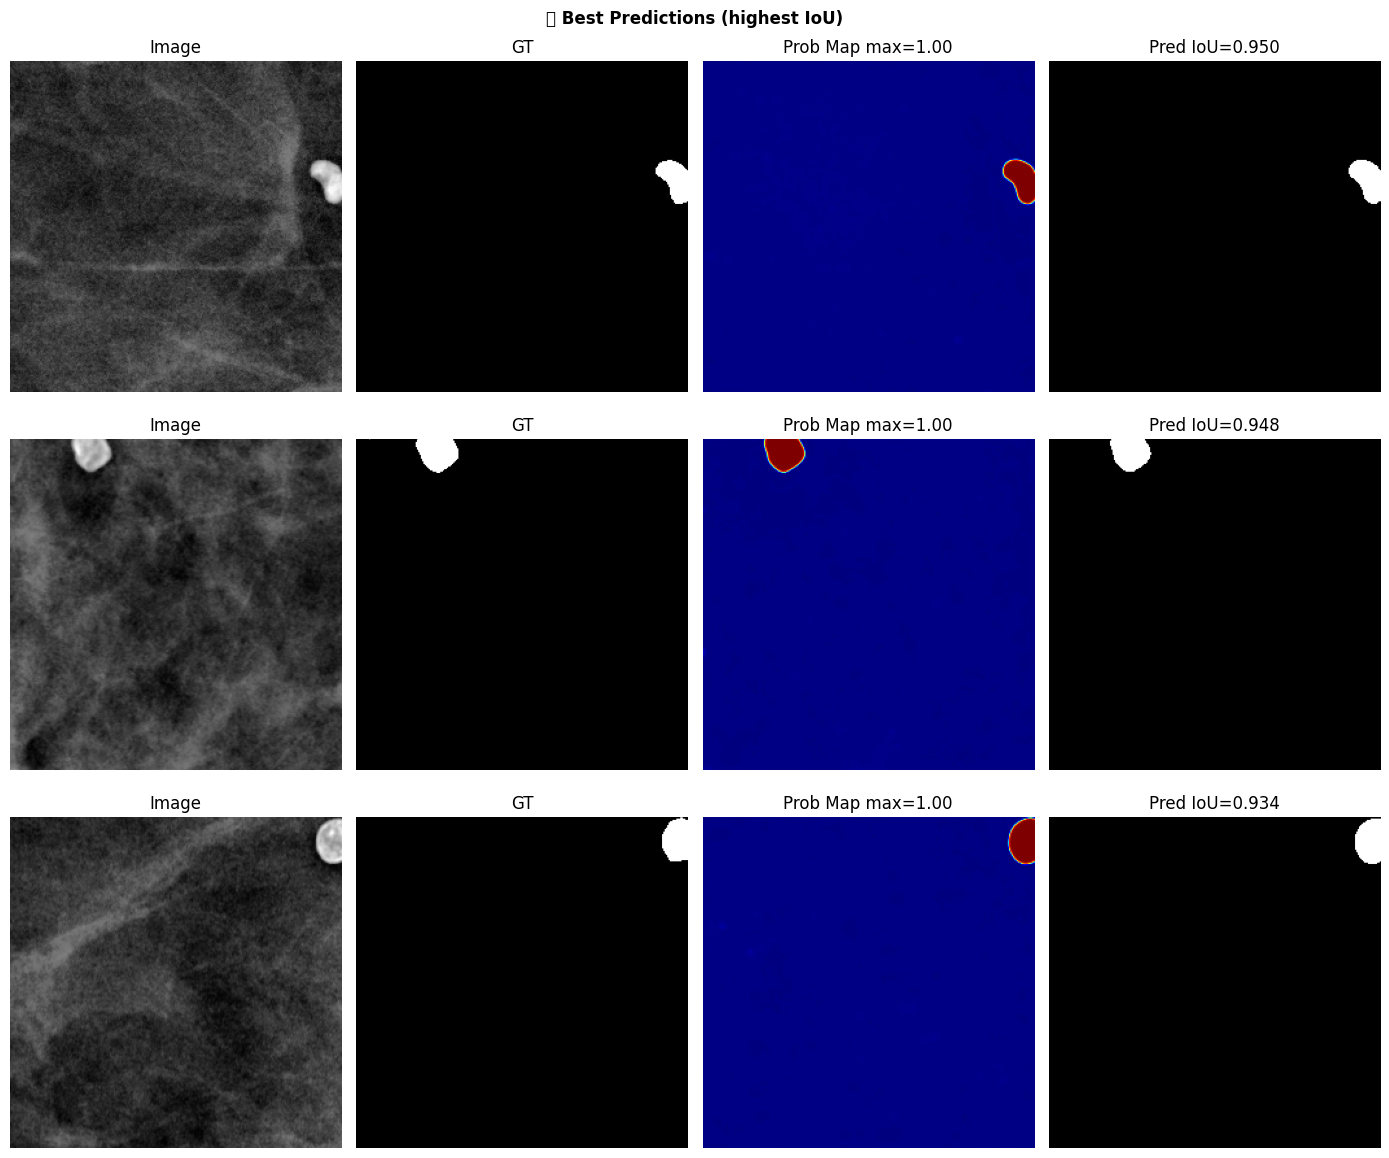

C:\Users\amine\AppData\Local\Temp\ipykernel_11092\464767592.py:23: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\project\mammo-cad\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


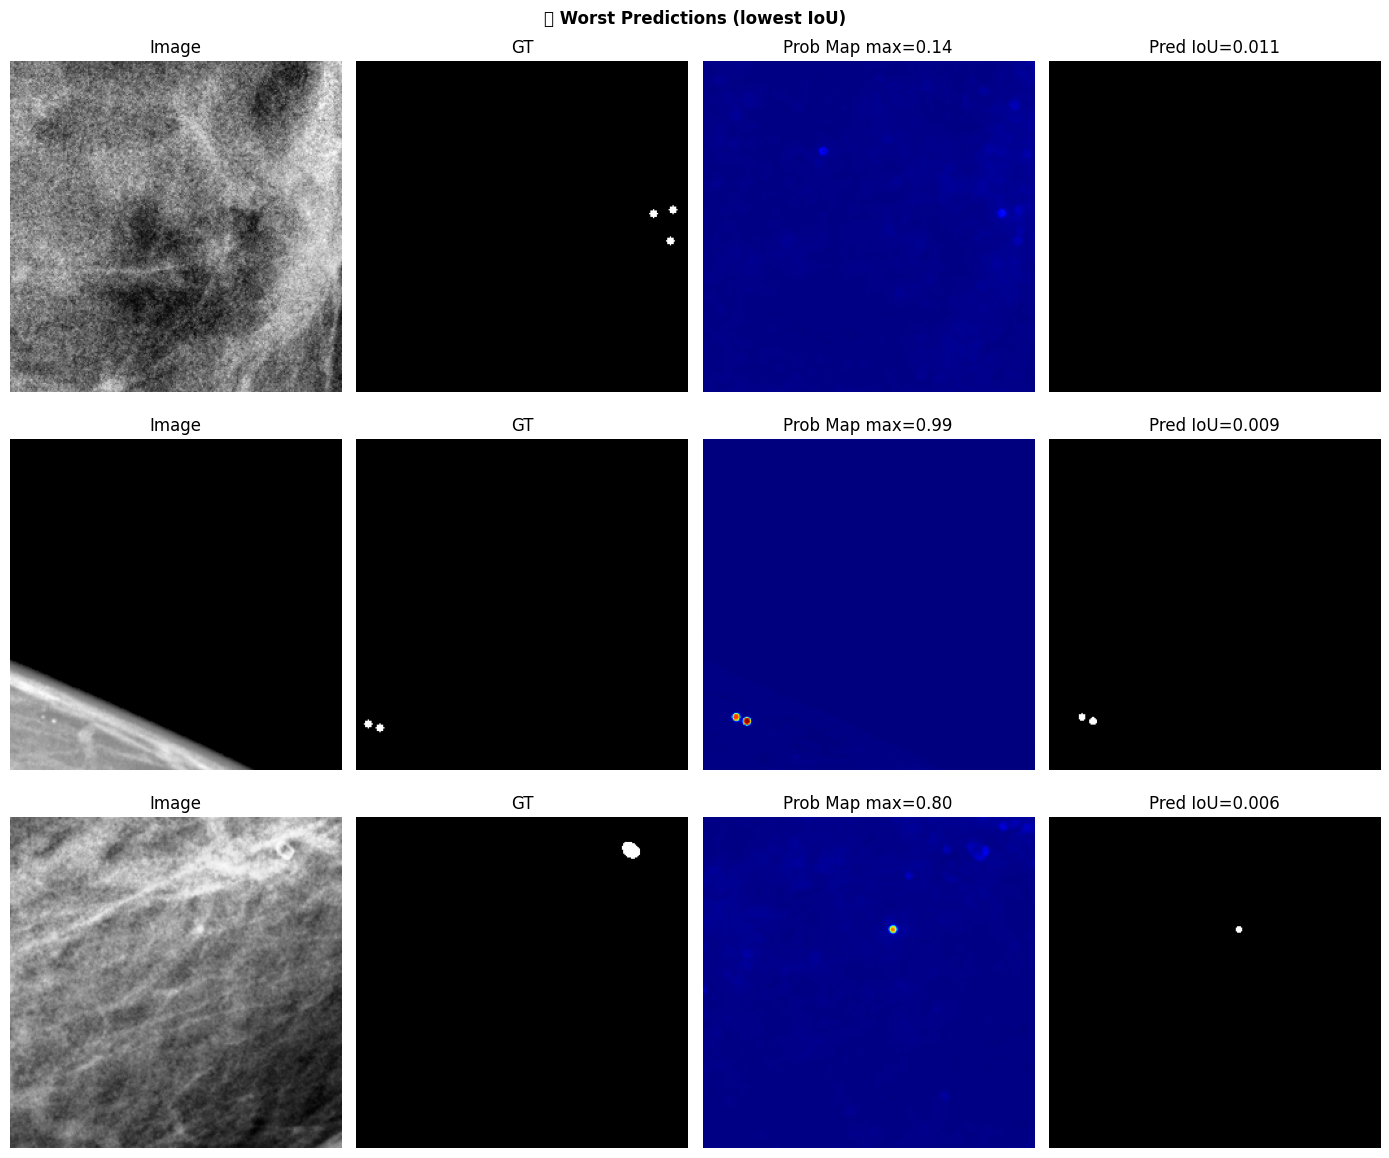

In [5]:
# Sort by IoU
scored = sorted(zip(all_ious, test_imgs, test_masks), reverse=True)
best3  = scored[:3]
worst3 = scored[-3:]

def show_predictions(cases, title):
    fig, axes = plt.subplots(len(cases), 4, figsize=(14, 4*len(cases)))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    for row, (iou_val, ip, mp) in enumerate(cases):
        img  = cv2.imread(str(ip), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
        t = torch.tensor(img.astype(np.float32)/255.).unsqueeze(0).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            prob   = torch.sigmoid(model(t)).cpu().numpy()[0,0]
        binary = (prob > 0.5).astype(np.float32)
        mask_b = (mask > 0).astype(np.float32)

        axes[row,0].imshow(img,    cmap='gray'); axes[row,0].set_title('Image');  axes[row,0].axis('off')
        axes[row,1].imshow(mask_b, cmap='gray'); axes[row,1].set_title('GT');     axes[row,1].axis('off')
        axes[row,2].imshow(prob,   cmap='jet', vmin=0, vmax=1)
        axes[row,2].set_title(f'Prob Map max={prob.max():.2f}'); axes[row,2].axis('off')
        axes[row,3].imshow(binary, cmap='gray'); axes[row,3].set_title(f'Pred IoU={iou_val:.3f}'); axes[row,3].axis('off')
    plt.tight_layout(); plt.show()

show_predictions(best3,  '✅ Best Predictions (highest IoU)')
show_predictions(worst3, '❌ Worst Predictions (lowest IoU)')

## 5. Threshold Analysis

  Threshold 0.2 → IoU=0.5406 Dice=0.6483 Sens=0.7949
  Threshold 0.3 → IoU=0.5581 Dice=0.6607 Sens=0.7613
  Threshold 0.4 → IoU=0.5674 Dice=0.6651 Sens=0.7322
  Threshold 0.5 → IoU=0.5694 Dice=0.6654 Sens=0.7015
  Threshold 0.6 → IoU=0.5617 Dice=0.6583 Sens=0.6642
  Threshold 0.7 → IoU=0.5447 Dice=0.6454 Sens=0.6212

Best threshold: 0.5 → IoU=0.5694


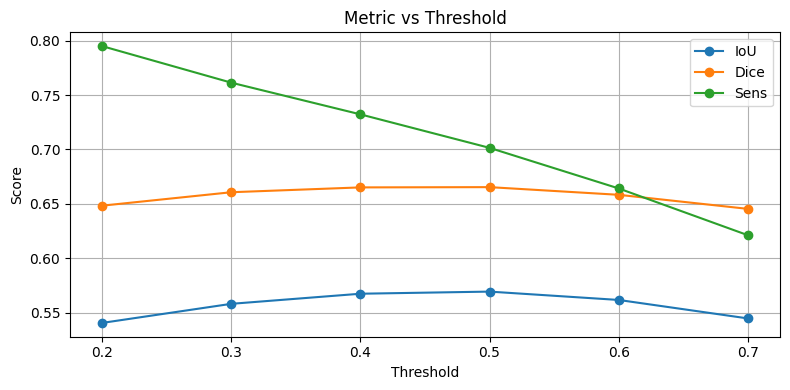

In [6]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
th_results = {}

for th in thresholds:
    ious, dices, senss = [], [], []
    for img_path, mask_path in zip(test_imgs, test_masks):
        img  = cv2.imread(str(img_path),  cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        t = torch.tensor(img.astype(np.float32)/255.).unsqueeze(0).unsqueeze(0).to(DEVICE)
        m = torch.tensor((mask>0).astype(np.float32)).unsqueeze(0).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = model(t)
        ious.append(iou_coefficient(logits, m, threshold=th))
        dices.append(dice_coefficient(logits, m, threshold=th))
        senss.append(sensitivity_score(logits, m, threshold=th))
    th_results[th] = {'IoU': np.mean(ious), 'Dice': np.mean(dices), 'Sens': np.mean(senss)}
    print(f'  Threshold {th:.1f} → IoU={np.mean(ious):.4f} Dice={np.mean(dices):.4f} Sens={np.mean(senss):.4f}')

best_th = max(th_results, key=lambda k: th_results[k]['IoU'])
print(f'\nBest threshold: {best_th} → IoU={th_results[best_th]["IoU"]:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(8,4))
for metric in ['IoU','Dice','Sens']:
    ax.plot(thresholds, [th_results[t][metric] for t in thresholds], 'o-', label=metric)
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Metric vs Threshold'); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

## 6. IoU Distribution

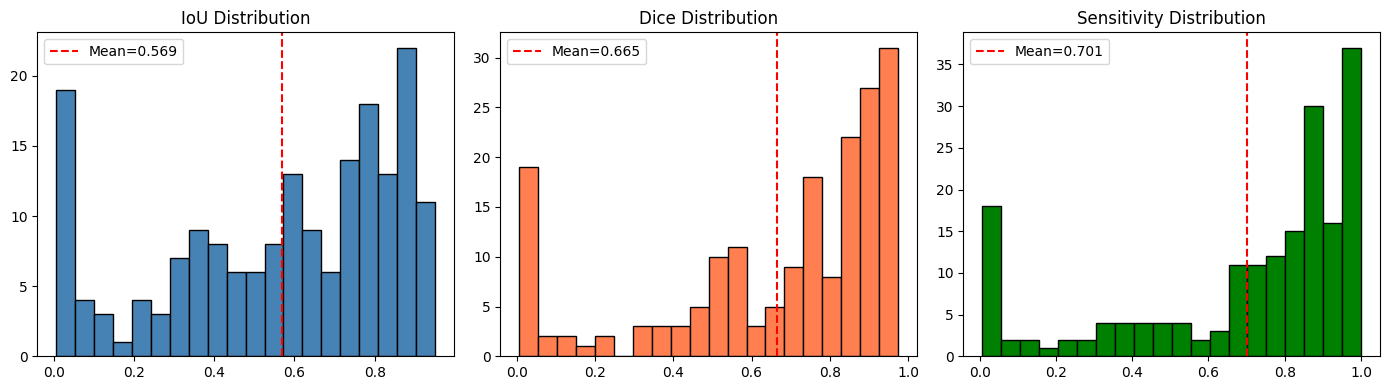


=== FINAL RESULTS FOR PFE REPORT ===
Model: U-Net (base_ch=64) | Loss: topk_CE (OHEM) | 10-fold CV
Dataset: INbreast (184 test patches)
IoU    : 0.5694 ± 0.2870
Dice   : 0.6654 ± 0.2955
Sens   : 0.7015 ± 0.3082
AUC-ROC: 0.9642
AUC-PR : 0.8009
Best threshold: 0.5


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(all_ious,  bins=20, color='steelblue', edgecolor='black')
axes[0].axvline(np.mean(all_ious), color='red', linestyle='--',
                label=f'Mean={np.mean(all_ious):.3f}')
axes[0].set_title('IoU Distribution'); axes[0].legend()

axes[1].hist(all_dices, bins=20, color='coral', edgecolor='black')
axes[1].axvline(np.mean(all_dices), color='red', linestyle='--',
                label=f'Mean={np.mean(all_dices):.3f}')
axes[1].set_title('Dice Distribution'); axes[1].legend()

axes[2].hist(all_sens, bins=20, color='green', edgecolor='black')
axes[2].axvline(np.mean(all_sens), color='red', linestyle='--',
                label=f'Mean={np.mean(all_sens):.3f}')
axes[2].set_title('Sensitivity Distribution'); axes[2].legend()
plt.tight_layout(); plt.show()

# Final summary for PFE report
print('\n=== FINAL RESULTS FOR PFE REPORT ===')
print(f'Model: U-Net (base_ch=64) | Loss: topk_CE (OHEM) | 10-fold CV')
print(f'Dataset: INbreast ({len(test_imgs)} test patches)')
print(f'IoU    : {np.mean(all_ious):.4f} ± {np.std(all_ious):.4f}')
print(f'Dice   : {np.mean(all_dices):.4f} ± {np.std(all_dices):.4f}')
print(f'Sens   : {np.mean(all_sens):.4f} ± {np.std(all_sens):.4f}')
print(f'AUC-ROC: {auc_roc:.4f}')
print(f'AUC-PR : {auc_pr:.4f}')
print(f'Best threshold: {best_th}')

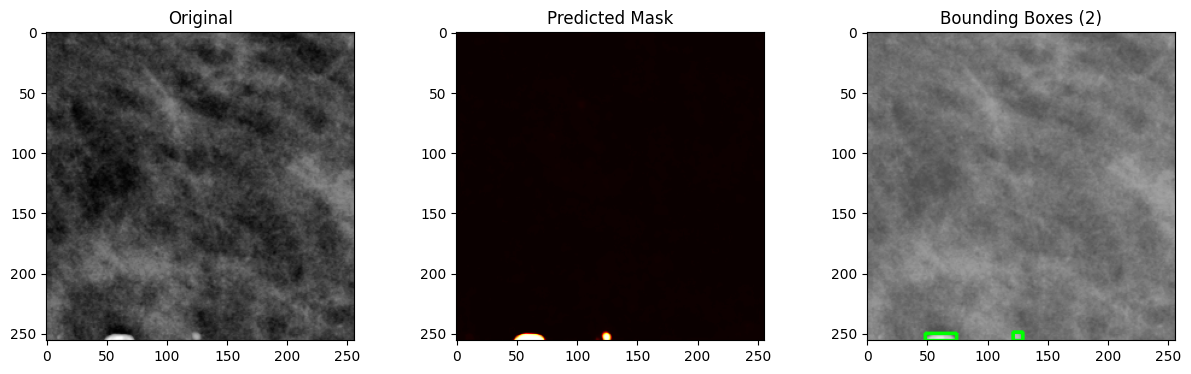

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

# ==============================
# MULTI-BOUNDING BOX EXTRACTION
# ==============================
def get_bounding_boxes(mask, thresh=0.3, min_area=20):
    """
    Extract multiple bounding boxes using connected components
    """
    mask_bin = (mask > thresh).astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_bin)

    boxes = []
    for i in range(1, num_labels):  # skip background (0)
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]

        if area >= min_area:  # filter noise
            boxes.append((x, y, x+w, y+h))

    return boxes


def draw_boxes(image, boxes):
    """
    Draw multiple bounding boxes
    """
    img = image.copy()

    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    for (x1, y1, x2, y2) in boxes:
        cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)

    return img


# ==============================
# LOAD IMAGE
# ==============================
img_path = test_imgs[0]

img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
img_norm = img / 255.0

# ==============================
# PYTORCH PREDICTION
# ==============================
model.eval()

with torch.no_grad():
    img_tensor = torch.tensor(img_norm, dtype=torch.float32)\
                        .unsqueeze(0).unsqueeze(0)

    img_tensor = img_tensor.to(next(model.parameters()).device)

    logits = model(img_tensor)
    pred = torch.sigmoid(logits)

    pred = pred.squeeze().cpu().numpy()

# ==============================
# GET MULTIPLE BOXES
# ==============================
boxes = get_bounding_boxes(pred, thresh=0.3, min_area=15)

# ==============================
# DRAW
# ==============================
img_boxes = draw_boxes(img, boxes)

# ==============================
# VISUALIZATION
# ==============================
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img, cmap='gray')

plt.subplot(1,3,2)
plt.title("Predicted Mask")
plt.imshow(pred, cmap='hot')

plt.subplot(1,3,3)
plt.title(f"Bounding Boxes ({len(boxes)})")
plt.imshow(img_boxes)

plt.show()